In [1]:
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )
    device = torch.device("cuda")
else:
    print("Using CPU")
    device = torch.device("cpu")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn

from transformers import (
    AutoImageProcessor,
    SiglipForImageClassification
)

print("Imports successful.")

Imports successful.


In [3]:
INPUT_ROOT = Path("/kaggle/input")

dataset_candidates = [
    p
    for p in INPUT_ROOT.rglob("kaggle_dataset")
    if p.is_dir()
]

print("Dataset candidates:")

for p in dataset_candidates:
    print(p)

if not dataset_candidates:
    raise FileNotFoundError(
        "GeoSigLIP dataset not found."
    )

DATA_ROOT = dataset_candidates[0]

print("\nDATA_ROOT:")
print(DATA_ROOT)

Dataset candidates:
/kaggle/input/datasets/utkarshrode/geosiglip-dcid-7-lithology-dataset/kaggle_dataset

DATA_ROOT:
/kaggle/input/datasets/utkarshrode/geosiglip-dcid-7-lithology-dataset/kaggle_dataset


In [4]:
CHECKPOINT_ROOT = (
    INPUT_ROOT
    / "datasets"
    / "utkarshrode"
    / "geosiglip-lora-checkpoint"
    / "best_model"
)

print(
    "Checkpoint directory:",
    CHECKPOINT_ROOT
)

if not CHECKPOINT_ROOT.exists():
    raise FileNotFoundError(
        f"Checkpoint directory not found:\n"
        f"{CHECKPOINT_ROOT}"
    )

print("\nCheckpoint files:")

for p in CHECKPOINT_ROOT.iterdir():
    print(p.name)


Checkpoint directory: /kaggle/input/datasets/utkarshrode/geosiglip-lora-checkpoint/best_model

Checkpoint files:
.format_version
.storage_alignment
data.pkl
.data
version
byteorder
data


In [5]:
CLASS_NAMES = [
    "Red sandstone",
    "Light sandstone",
    "Gray siltstone",
    "Mudstone",
    "Granite",
    "Basalt",
    "Marble"
]

LABEL2ID = {
    name: i
    for i, name in enumerate(CLASS_NAMES)
}

ID2LABEL = {
    i: name
    for i, name in enumerate(CLASS_NAMES)
}

NUM_CLASSES = 7

print("Classes:")

for i, name in enumerate(CLASS_NAMES):
    print(
        f"{i}: {name}"
    )

Classes:
0: Red sandstone
1: Light sandstone
2: Gray siltstone
3: Mudstone
4: Granite
5: Basalt
6: Marble


In [6]:
MODEL_NAME = (
    "google/siglip-base-patch16-224"
)

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

print("Model:", MODEL_NAME)
print("LoRA rank:", LORA_R)
print("LoRA alpha:", LORA_ALPHA)
print("LoRA dropout:", LORA_DROPOUT)

Model: google/siglip-base-patch16-224
LoRA rank: 16
LoRA alpha: 32
LoRA dropout: 0.05


In [7]:
processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME
)

print(
    "Image processor loaded."
)

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Image processor loaded.


In [8]:
class LoRALinear(nn.Module):

    def __init__(
        self,
        base_layer,
        rank=16,
        alpha=32,
        dropout=0.05
    ):
        super().__init__()

        if not isinstance(
            base_layer,
            nn.Linear
        ):
            raise TypeError(
                "base_layer must be nn.Linear"
            )

        self.base_layer = base_layer

        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank

        # Freeze pretrained layer
        for parameter in (
            self.base_layer.parameters()
        ):
            parameter.requires_grad = False

        layer_device = (
            base_layer.weight.device
        )

        layer_dtype = (
            base_layer.weight.dtype
        )

        self.lora_A = nn.Linear(
            base_layer.in_features,
            rank,
            bias=False,
            device=layer_device,
            dtype=layer_dtype
        )

        self.lora_B = nn.Linear(
            rank,
            base_layer.out_features,
            bias=False,
            device=layer_device,
            dtype=layer_dtype
        )

        self.dropout = nn.Dropout(
            dropout
        )

        # Same initialization used during training
        nn.init.kaiming_uniform_(
            self.lora_A.weight,
            a=np.sqrt(5)
        )

        nn.init.zeros_(
            self.lora_B.weight
        )

    def forward(self, x):

        base_output = self.base_layer(x)

        lora_output = self.lora_B(
            self.lora_A(
                self.dropout(x)
            )
        )

        return (
            base_output
            + self.scaling * lora_output
        )

In [9]:
model = (
    SiglipForImageClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=NUM_CLASSES,
        label2id=LABEL2ID,
        id2label=ID2LABEL,
        ignore_mismatched_sizes=True
    )
    .to(device)
)

# Freeze all pretrained parameters
for parameter in model.parameters():
    parameter.requires_grad = False


# Recreate LoRA layers
for layer in (
    model
    .vision_model
    .encoder
    .layers
):

    layer.self_attn.q_proj = LoRALinear(
        layer.self_attn.q_proj,
        rank=LORA_R,
        alpha=LORA_ALPHA,
        dropout=LORA_DROPOUT
    )

    layer.self_attn.v_proj = LoRALinear(
        layer.self_attn.v_proj,
        rank=LORA_R,
        alpha=LORA_ALPHA,
        dropout=LORA_DROPOUT
    )


# Enable LoRA parameters
for layer in (
    model
    .vision_model
    .encoder
    .layers
):

    for parameter in (
        layer.self_attn.q_proj
        .lora_A.parameters()
    ):
        parameter.requires_grad = True

    for parameter in (
        layer.self_attn.q_proj
        .lora_B.parameters()
    ):
        parameter.requires_grad = True

    for parameter in (
        layer.self_attn.v_proj
        .lora_A.parameters()
    ):
        parameter.requires_grad = True

    for parameter in (
        layer.self_attn.v_proj
        .lora_B.parameters()
    ):
        parameter.requires_grad = True


# Classifier is trained
for parameter in (
    model.classifier.parameters()
):
    parameter.requires_grad = True


model = model.to(device)
model.eval()

print(
    "Exact GeoSigLIP LoRA architecture created."
)

config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SiglipForImageClassification LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     | 
-------------------------------------------------------------+------------+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |

Exact GeoSigLIP LoRA architecture created.


In [10]:
REBUILT_CHECKPOINT = Path(
    "/kaggle/working/geosiglip_best_model.pt"
)

if REBUILT_CHECKPOINT.exists():
    REBUILT_CHECKPOINT.unlink()

with zipfile.ZipFile(
    REBUILT_CHECKPOINT,
    "w",
    compression=zipfile.ZIP_STORED
) as archive:

    for file_path in CHECKPOINT_ROOT.rglob("*"):

        if file_path.is_file():

            relative_path = (
                file_path.relative_to(
                    CHECKPOINT_ROOT
                )
            )

            archive_path = (
                Path("best_model")
                / relative_path
            )

            archive.write(
                file_path,
                arcname=str(
                    archive_path
                )
            )

print(
    "Checkpoint rebuilt:"
)

print(REBUILT_CHECKPOINT)

print(
    "Size:",
    round(
        REBUILT_CHECKPOINT.stat().st_size
        / (1024 ** 2),
        2
    ),
    "MB"
)

Checkpoint rebuilt:
/kaggle/working/geosiglip_best_model.pt
Size: 356.68 MB


In [11]:
checkpoint = torch.load(
    REBUILT_CHECKPOINT,
    map_location=device,
    weights_only=True
)

print(
    "Checkpoint tensors:",
    len(checkpoint)
)

result = model.load_state_dict(
    checkpoint,
    strict=True
)

print(
    "Missing keys:",
    len(result.missing_keys)
)

print(
    "Unexpected keys:",
    len(result.unexpected_keys)
)

if (
    len(result.missing_keys) != 0
    or len(result.unexpected_keys) != 0
):
    raise RuntimeError(
        "Checkpoint/model architecture mismatch."
    )

model.eval()

print(
    "\nGeoSigLIP LoRA checkpoint loaded successfully."
)

Checkpoint tensors: 258
Missing keys: 0
Unexpected keys: 0

GeoSigLIP LoRA checkpoint loaded successfully.


In [12]:
def predict_image(
    image,
    top_k=3
):

    if image is None:
        return None

    if not isinstance(
        image,
        Image.Image
    ):
        image = Image.fromarray(
            np.asarray(image)
        )

    image = image.convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    pixel_values = (
        inputs["pixel_values"]
        .to(device)
    )

    with torch.no_grad():

        outputs = model(
            pixel_values=pixel_values
        )

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )[0]

    values, indices = torch.topk(
        probabilities,
        k=min(
            top_k,
            NUM_CLASSES
        )
    )

    results = []

    for probability, index in zip(
        values.cpu().tolist(),
        indices.cpu().tolist()
    ):

        results.append({
            "Lithology": ID2LABEL[index],
            "Confidence": (
                f"{probability * 100:.2f}%"
            )
        })

    return pd.DataFrame(results)

Sample: /kaggle/input/datasets/utkarshrode/geosiglip-dcid-7-lithology-dataset/kaggle_dataset/images/test/Red sandstone/1.Red sandstone_919.jpg


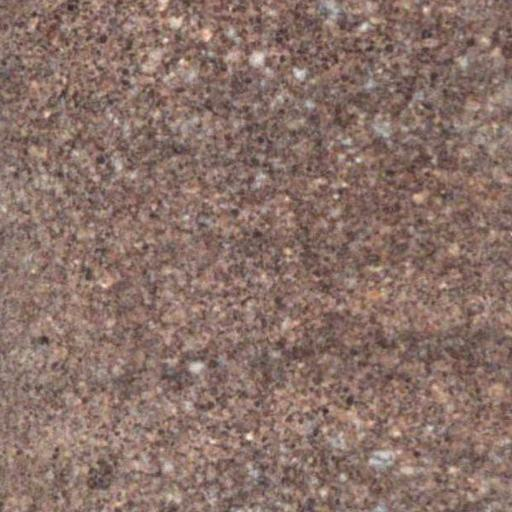

,Lithology,Confidence
0,Red sandstone,99.98%
1,Light sandstone,0.01%
2,Basalt,0.00%


In [13]:
test_csv = pd.read_csv(
    DATA_ROOT / "test.csv"
)

sample_path = (
    DATA_ROOT
    / test_csv.iloc[0]["image_path"]
)

sample_image = Image.open(
    sample_path
).convert("RGB")

print(
    "Sample:",
    sample_path
)

display(sample_image)

sample_result = predict_image(
    sample_image,
    top_k=3
)

display(sample_result)

In [14]:
def predict_for_display(
    image
):

    result = predict_image(
        image,
        top_k=3
    )

    if result is None:
        return "Please upload an image."

    output = []

    for i, row in result.iterrows():

        output.append(
            f"{i + 1}. "
            f"{row['Lithology']} — "
            f"{row['Confidence']}"
        )

    return "\n".join(output)

In [15]:
try:
    import gradio as gr

    print(
        "Gradio version:",
        gr.__version__
    )

except ImportError:

    raise ImportError(
        "Gradio is not available in this Kaggle environment."
    )

Gradio version: 5.50.0


In [16]:
def classify_rock(image):

    if image is None:

        return (
            "No image uploaded.",
            pd.DataFrame(
                columns=[
                    "Lithology",
                    "Confidence"
                ]
            )
        )

    result = predict_image(
        image,
        top_k=3
    )

    predicted_class = (
        result.iloc[0]["Lithology"]
    )

    confidence = (
        result.iloc[0]["Confidence"]
    )

    summary = (
        f"Predicted Lithology: "
        f"{predicted_class}\n\n"
        f"Confidence: {confidence}"
    )

    return (
        summary,
        result
    )


demo = gr.Interface(
    fn=classify_rock,

    inputs=gr.Image(
        type="pil",
        label="Upload Rock Image"
    ),

    outputs=[
        gr.Textbox(
            label="Prediction"
        ),

        gr.Dataframe(
            headers=[
                "Lithology",
                "Confidence"
            ],
            datatype=[
                "str",
                "str"
            ],
            label="Top-3 Predictions"
        )
    ],

    title="GeoSigLIP — Lithology Classifier",

    description=(
        "Upload a geological rock image. "
        "GeoSigLIP predicts the lithology "
        "using the LoRA fine-tuned SigLIP model."
    ),

    examples=None
)

print(
    "GeoSigLIP application created."
)

GeoSigLIP application created.


In [17]:
demo.launch(
    share=False,
    debug=False
)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.



Actual: Red sandstone


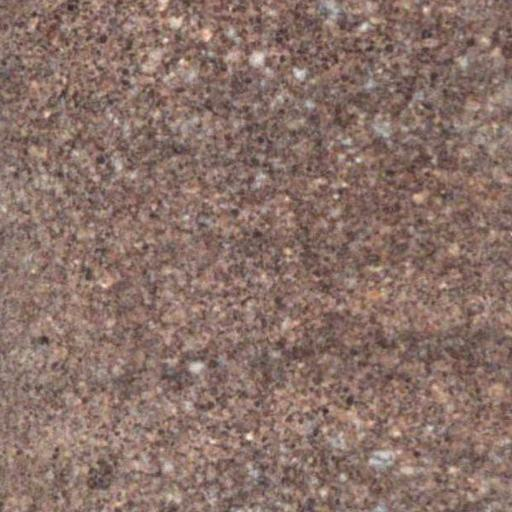

,Lithology,Confidence
0,Red sandstone,99.98%
1,Light sandstone,0.01%
2,Basalt,0.00%



Actual: Red sandstone


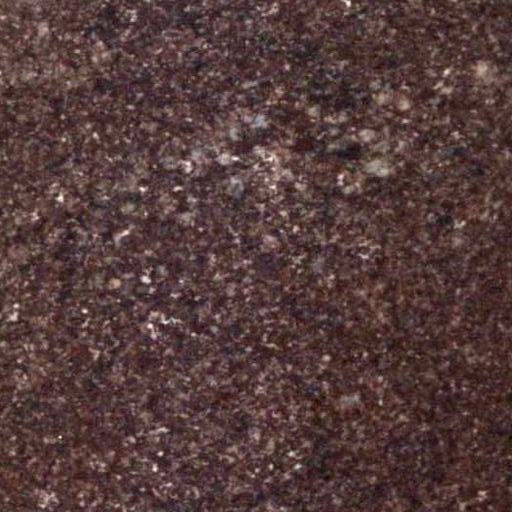

,Lithology,Confidence
0,Red sandstone,99.96%
1,Basalt,0.02%
2,Light sandstone,0.01%



Actual: Red sandstone


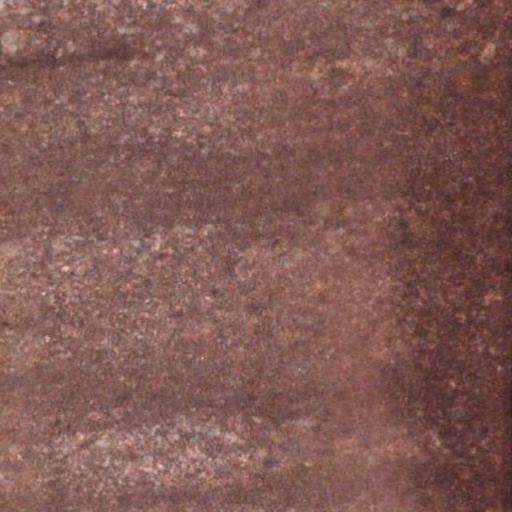

,Lithology,Confidence
0,Red sandstone,99.98%
1,Light sandstone,0.01%
2,Gray siltstone,0.00%



Actual: Red sandstone


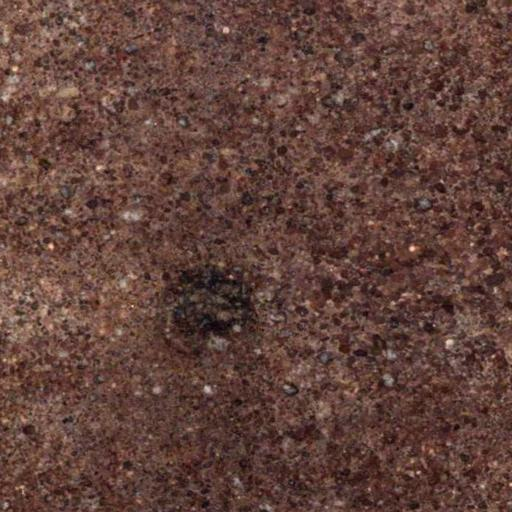

,Lithology,Confidence
0,Red sandstone,99.99%
1,Light sandstone,0.01%
2,Mudstone,0.00%



Actual: Red sandstone


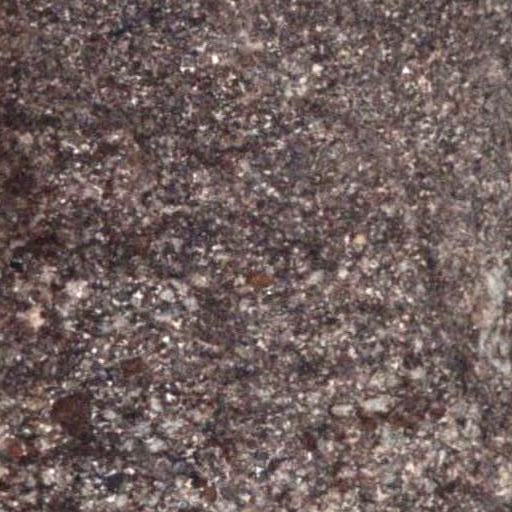

,Lithology,Confidence
0,Red sandstone,99.98%
1,Basalt,0.01%
2,Light sandstone,0.01%


In [18]:
sample_indices = [0, 1, 2, 3, 4]

for index in sample_indices:

    image_path = (
        DATA_ROOT
        / test_csv.iloc[index]["image_path"]
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    result = predict_image(
        image,
        top_k=3
    )

    print(
        "\nActual:",
        test_csv.iloc[index]["label"]
    )

    display(image)

    display(result)

In [19]:
deployment_config = {
    "model": MODEL_NAME,

    "task": "7-class lithology classification",

    "classes": CLASS_NAMES,

    "fine_tuning": {
        "method": "LoRA",
        "rank": LORA_R,
        "alpha": LORA_ALPHA,
        "dropout": LORA_DROPOUT,
        "target_modules": [
            "q_proj",
            "v_proj"
        ]
    },

    "input": {
        "image_size": "224x224",
        "format": "RGB"
    },

    "outputs": [
        "predicted lithology",
        "confidence",
        "top-3 predictions"
    ]
}

with open(
    "/kaggle/working/"
    "deployment_config.json",
    "w"
) as f:

    import json

    json.dump(
        deployment_config,
        f,
        indent=4
    )

print(
    "deployment_config.json saved."
)

deployment_config.json saved.


In [20]:
inference_script = r'''
import numpy as np
import torch
import torch.nn as nn

from PIL import Image
from transformers import (
    AutoImageProcessor,
    SiglipForImageClassification
)


MODEL_NAME = "google/siglip-base-patch16-224"

CLASS_NAMES = [
    "Red sandstone",
    "Light sandstone",
    "Gray siltstone",
    "Mudstone",
    "Granite",
    "Basalt",
    "Marble"
]


class LoRALinear(nn.Module):

    def __init__(
        self,
        base_layer,
        rank=16,
        alpha=32,
        dropout=0.05
    ):

        super().__init__()

        self.base_layer = base_layer

        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank

        for p in self.base_layer.parameters():
            p.requires_grad = False

        device = base_layer.weight.device
        dtype = base_layer.weight.dtype

        self.lora_A = nn.Linear(
            base_layer.in_features,
            rank,
            bias=False,
            device=device,
            dtype=dtype
        )

        self.lora_B = nn.Linear(
            rank,
            base_layer.out_features,
            bias=False,
            device=device,
            dtype=dtype
        )

        self.dropout = nn.Dropout(dropout)

        nn.init.kaiming_uniform_(
            self.lora_A.weight,
            a=np.sqrt(5)
        )

        nn.init.zeros_(
            self.lora_B.weight
        )

    def forward(self, x):

        return (
            self.base_layer(x)
            + self.scaling
            * self.lora_B(
                self.lora_A(
                    self.dropout(x)
                )
            )
        )


def build_model(checkpoint):

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    model = (
        SiglipForImageClassification
        .from_pretrained(
            MODEL_NAME,
            num_labels=7,
            label2id={
                name: i
                for i, name
                in enumerate(CLASS_NAMES)
            },
            id2label={
                i: name
                for i, name
                in enumerate(CLASS_NAMES)
            },
            ignore_mismatched_sizes=True
        )
        .to(device)
    )

    for p in model.parameters():
        p.requires_grad = False

    for layer in (
        model
        .vision_model
        .encoder
        .layers
    ):

        layer.self_attn.q_proj = LoRALinear(
            layer.self_attn.q_proj
        )

        layer.self_attn.v_proj = LoRALinear(
            layer.self_attn.v_proj
        )

    model.load_state_dict(
        torch.load(
            checkpoint,
            map_location=device,
            weights_only=True
        ),
        strict=True
    )

    model.eval()

    return model, device


def predict(
    image,
    model,
    processor,
    device,
    top_k=3
):

    image = image.convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    with torch.no_grad():

        outputs = model(
            pixel_values=(
                inputs[
                    "pixel_values"
                ].to(device)
            )
        )

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )[0]

    values, indices = torch.topk(
        probabilities,
        k=top_k
    )

    return [
        {
            "lithology":
                CLASS_NAMES[index],

            "confidence":
                float(value)
        }

        for value, index
        in zip(
            values.cpu().tolist(),
            indices.cpu().tolist()
        )
    ]
'''

with open(
    "/kaggle/working/inference.py",
    "w"
) as f:
    f.write(inference_script)

print(
    "inference.py created."
)

inference.py created.


In [21]:
print("=" * 70)
print("GEOSIGLIP — DEPLOYMENT COMPLETE")
print("=" * 70)

print("\nMODEL")
print(MODEL_NAME)

print("\nTASK")
print("7-class lithology classification")

print("\nCLASSES")
for name in CLASS_NAMES:
    print("-", name)

print("\nFINE-TUNING")
print("LoRA rank:", LORA_R)
print("LoRA alpha:", LORA_ALPHA)
print("LoRA dropout:", LORA_DROPOUT)
print("Targets: q_proj, v_proj")

print("\nAPPLICATION")
print("Image upload → lithology prediction")
print("Top-3 predictions")
print("Confidence scores")

print("\nARTIFACTS")
print("/kaggle/working/deployment_config.json")
print("/kaggle/working/inference.py")

print("\nGeoSigLIP deployment notebook complete.")

GEOSIGLIP — DEPLOYMENT COMPLETE

MODEL
google/siglip-base-patch16-224

TASK
7-class lithology classification

CLASSES
- Red sandstone
- Light sandstone
- Gray siltstone
- Mudstone
- Granite
- Basalt
- Marble

FINE-TUNING
LoRA rank: 16
LoRA alpha: 32
LoRA dropout: 0.05
Targets: q_proj, v_proj

APPLICATION
Image upload → lithology prediction
Top-3 predictions
Confidence scores

ARTIFACTS
/kaggle/working/deployment_config.json
/kaggle/working/inference.py

GeoSigLIP deployment notebook complete.
